In [ ]:
# Enhanced YOLOv8 Training Pipeline with Advanced Augmentations
# Target: 90+ mAP Accuracy

from ultralytics import YOLO
import os
import torch
from pathlib import Path
import yaml

# ==================== CONFIGURATION ====================
BASE_DIR = "/content/drive/MyDrive/Dataset"
DATA_YAML = os.path.join(BASE_DIR, "dataset.yaml")
PROJECT_DIR = os.path.join(BASE_DIR, "YOLO_training_enhanced")
MODEL_NAME = "yolov8m_high_accuracy"

# Enhanced Training Parameters for Higher Accuracy
EPOCHS = 150  # Increased epochs for better convergence
IMG_SIZE = 640  # Can increase to 1280 for better accuracy if GPU allows
BATCH_SIZE = 16  # Adjust based on GPU memory
CONF_THRESHOLD = 0.25
PATIENCE = 50  # Increased patience for early stopping

# ==================== GPU VERIFICATION ====================
if torch.cuda.is_available():
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = 0
else:
    print("⚠️ No GPU detected. Training will be slow on CPU.")
    device = 'cpu'

# ==================== DATASET VALIDATION ====================
print("\n📁 Validating dataset structure...")
required_dirs = [
    os.path.join(BASE_DIR, "images/train"),
    os.path.join(BASE_DIR, "images/val"),
    os.path.join(BASE_DIR, "labels/train"),
    os.path.join(BASE_DIR, "labels/val")
]

total_train_images = 0
total_val_images = 0

for dir_path in required_dirs:
    if not os.path.exists(dir_path):
        print(f"❌ Missing directory: {dir_path}")
        raise FileNotFoundError(f"Required directory not found: {dir_path}")
    else:
        file_count = len(os.listdir(dir_path))
        print(f"✅ {dir_path}: {file_count} files")
        if "train" in dir_path and "images" in dir_path:
            total_train_images = file_count
        elif "val" in dir_path and "images" in dir_path:
            total_val_images = file_count

print(f"\n📊 Dataset Statistics:")
print(f"   Training images: {total_train_images}")
print(f"   Validation images: {total_val_images}")

# ==================== CREATE ENHANCED DATASET.YAML ====================
# This includes augmentation settings in the YAML
yaml_content = f"""path: {BASE_DIR}
train: images/train
val: images/val
test: images/val  # Optional: add test set if available

# Classes
nc: 5
names: ['Auto', 'Bike', 'Bus', 'Car', 'Truck']

# Download script (optional)
download: null
"""

with open(DATA_YAML, "w") as f:
    f.write(yaml_content)
print("✅ Enhanced dataset.yaml created!")

# ==================== LOAD MODEL ====================
print("\n🔄 Loading YOLOv8m pretrained model...")
model = YOLO("yolov8m.pt")

# ==================== ENHANCED TRAINING WITH AUGMENTATIONS ====================
print(f"\n🚀 Starting ENHANCED training for {EPOCHS} epochs...")
print(f"   Strategy: Maximum augmentation + Extended training")
print(f"   Target: 90+ mAP accuracy")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE}")

try:
    results = model.train(
        data=DATA_YAML,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=device,
        project=PROJECT_DIR,
        name=MODEL_NAME,
        exist_ok=False,
        pretrained=True,

        # ========== OPTIMIZER SETTINGS ==========
        optimizer='AdamW',  # Better optimizer for convergence
        lr0=0.01,  # Initial learning rate (increased for better convergence)
        lrf=0.001,  # Final learning rate factor
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=5.0,  # Increased warmup
        warmup_momentum=0.8,
        warmup_bias_lr=0.1,

        # ========== LOSS WEIGHTS (Fine-tuned) ==========
        box=7.5,  # Box loss gain
        cls=0.5,  # Classification loss gain
        dfl=1.5,  # Distribution focal loss gain

        # ========== AUGMENTATION SETTINGS (CRITICAL FOR HIGH ACCURACY) ==========
        # Geometric Augmentations
        degrees=15.0,  # Image rotation (+/- degrees)
        translate=0.2,  # Image translation (+/- fraction)
        scale=0.9,  # Image scale gain (+/- gain)
        shear=5.0,  # Image shear (+/- degrees)
        perspective=0.0005,  # Image perspective (+/- fraction)
        flipud=0.5,  # Vertical flip probability
        fliplr=0.5,  # Horizontal flip probability

        # Color Augmentations
        hsv_h=0.015,  # HSV-Hue augmentation
        hsv_s=0.7,  # HSV-Saturation augmentation
        hsv_v=0.4,  # HSV-Value augmentation

        # Advanced Augmentations
        mosaic=1.0,  # Mosaic augmentation probability
        mixup=0.15,  # MixUp augmentation probability

        # Augmentation Control
        close_mosaic=20,  # Disable mosaic in last N epochs for fine-tuning

        # ========== REGULARIZATION ==========
        dropout=0.1,  # Dropout probability (add if supported)

        # ========== TRAINING SETTINGS ==========
        patience=PATIENCE,  # Early stopping patience
        save=True,
        save_period=10,  # Save checkpoint every 10 epochs
        cache='ram' if total_train_images < 10000 else False,  # Cache images in RAM/disk
        workers=8,  # Data loading threads
        plots=True,  # Save training plots
        verbose=True,
        seed=42,  # Reproducibility
        deterministic=False,
        single_cls=False,
        rect=False,  # Rectangular training
        cos_lr=True,  # Cosine learning rate scheduler

        # ========== PERFORMANCE SETTINGS ==========
        amp=True,  # Automatic Mixed Precision for faster training
        fraction=1.0,  # Use full dataset
        profile=False,

        # ========== VALIDATION ==========
        val=True,  # Validate during training
        save_json=False,

        # ========== MULTI-SCALE TRAINING ==========
        multi_scale=True,  # Multi-scale training (helps generalization)
    )

    print("\n✅ Training completed successfully!")

    # Display training results
    if hasattr(results, 'results_dict'):
        print("\n📊 Final Training Metrics:")
        for key, value in results.results_dict.items():
            if isinstance(value, float):
                print(f"   {key}: {value:.4f}")

except Exception as e:
    print(f"\n❌ Training failed with error: {str(e)}")
    print("\nTroubleshooting tips:")
    print("1. Reduce batch_size if out of memory")
    print("2. Reduce imgsz to 416 or 512 if needed")
    print("3. Set cache=False if RAM issues")
    print("4. Check dataset paths and formats")
    raise

# ==================== MODEL EVALUATION ====================
print("\n📊 Evaluating model on validation set...")
try:
    metrics = model.val(
        conf=0.001,  # Low confidence for validation to see all predictions
        iou=0.6,
        max_det=300
    )

    print(f"\n📈 Validation Metrics:")
    print(f"   mAP@50: {metrics.box.map50:.4f}")
    print(f"   mAP@50-95: {metrics.box.map:.4f}")
    print(f"   Precision: {metrics.box.mp:.4f}")
    print(f"   Recall: {metrics.box.mr:.4f}")

    # Per-class metrics
    if hasattr(metrics.box, 'ap_class_index'):
        class_names = ['Auto', 'Bike', 'Bus', 'Car', 'Truck']
        print("\n📊 Per-Class mAP@50:")
        for i, class_idx in enumerate(metrics.box.ap_class_index):
            if i < len(class_names):
                class_map = metrics.box.ap50[i] if hasattr(metrics.box, 'ap50') else 0
                print(f"   {class_names[class_idx]}: {class_map:.4f}")

    # Check if target accuracy achieved
    if metrics.box.map50 >= 0.90:
        print("\n🎯 TARGET ACHIEVED! mAP@50 is above 90%!")
    else:
        print(f"\n⚠️ Current mAP@50: {metrics.box.map50:.4f}")
        print("Tips to improve accuracy further:")
        print("1. Increase epochs to 300-500")
        print("2. Increase image size to 1280")
        print("3. Add more training data")
        print("4. Use data augmentation on your dataset")
        print("5. Fine-tune on your specific data after general training")

except Exception as e:
    print(f"⚠️ Validation failed: {str(e)}")

# ==================== LOAD BEST MODEL ====================
best_model_path = os.path.join(PROJECT_DIR, MODEL_NAME, "weights/best.pt")
last_model_path = os.path.join(PROJECT_DIR, MODEL_NAME, "weights/last.pt")

if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)
    print(f"\n✅ Loaded best model from: {best_model_path}")

    # ==================== TEST PREDICTIONS ====================
    print("\n🔮 Running enhanced predictions on validation images...")
    val_img_dir = os.path.join(BASE_DIR, "images/val")
    val_images = [f for f in os.listdir(val_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:10]

    if val_images:
        print(f"🖼️ Predicting on {len(val_images)} sample images...")

        for i, img_file in enumerate(val_images, 1):
            img_path = os.path.join(val_img_dir, img_file)

            # Run prediction with optimal settings
            results = best_model.predict(
                img_path,
                conf=CONF_THRESHOLD,
                iou=0.45,
                agnostic_nms=False,  # Class-specific NMS
                max_det=300,
                classes=None,  # Detect all classes
                retina_masks=True,
                save=True,
                save_txt=True,
                save_conf=True,
                save_crop=False,
                show_labels=True,
                show_conf=True,
                show_boxes=True,
                line_width=2,
                project=os.path.join(PROJECT_DIR, MODEL_NAME),
                name="predictions",
                exist_ok=True
            )

            # Display detection counts
            if results and len(results) > 0:
                num_detections = len(results[0].boxes) if results[0].boxes is not None else 0
                print(f"   [{i}/{len(val_images)}] {img_file}: {num_detections} detections")

        print(f"\n✅ Predictions saved to: {os.path.join(PROJECT_DIR, MODEL_NAME, 'predictions')}")
else:
    print(f"❌ Best model not found at: {best_model_path}")

# ==================== MODEL EXPORT ====================
print("\n📦 Exporting model to multiple formats...")
export_formats = ['onnx', 'torchscript', 'tflite']

for format_type in export_formats:
    try:
        print(f"   Exporting to {format_type.upper()}...")
        best_model.export(
            format=format_type,
            imgsz=IMG_SIZE,
            keras=False,
            optimize=True,
            half=False,
            int8=False,
            dynamic=True if format_type == 'onnx' else False,
            simplify=True if format_type == 'onnx' else False,
            opset=12 if format_type == 'onnx' else None,
            workspace=4,
            nms=False
        )
        print(f"   ✅ {format_type.upper()} export successful!")
    except Exception as e:
        print(f"   ⚠️ {format_type.upper()} export failed: {str(e)}")

# ==================== TRAINING SUMMARY ====================
print("\n" + "="*60)
print("🎉 ENHANCED TRAINING PIPELINE COMPLETED!")
print("="*60)
print(f"📂 Results location: {os.path.join(PROJECT_DIR, MODEL_NAME)}")
print(f"🏆 Best weights: {best_model_path}")
print(f"📊 Training plots: {os.path.join(PROJECT_DIR, MODEL_NAME, 'results.png')}")
print(f"📈 Confusion matrix: {os.path.join(PROJECT_DIR, MODEL_NAME, 'confusion_matrix.png')}")
print("\n💡 Next Steps for Even Higher Accuracy:")
print("1. Review confusion matrix to identify problematic classes")
print("2. Add more training samples for low-performing classes")
print("3. Implement test-time augmentation (TTA)")
print("4. Ensemble multiple models")
print("5. Use larger model (YOLOv8x) if GPU memory allows")
print("="*60)

✅ GPU detected: Tesla T4
   GPU Memory: 15.83 GB

📁 Validating dataset structure...
✅ /content/drive/MyDrive/Dataset/images/train: 1229 files
✅ /content/drive/MyDrive/Dataset/images/val: 351 files
✅ /content/drive/MyDrive/Dataset/labels/train: 1229 files
✅ /content/drive/MyDrive/Dataset/labels/val: 351 files

📊 Dataset Statistics:
   Training images: 1229
   Validation images: 351
✅ Enhanced dataset.yaml created!

🔄 Loading YOLOv8m pretrained model...

🚀 Starting ENHANCED training for 150 epochs...
   Strategy: Maximum augmentation + Extended training
   Target: 90+ mAP accuracy
   Batch size: 16
   Image size: 640x640
Ultralytics 8.3.208 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDri

In [ ]:
# Enhanced YOLOv8 Training Pipeline with Aggressive Augmentations for Fast High Accuracy
# Target: 90+ mAP with <=50 Epochs via Heavy Data Augmentation (Simulates 5x+ Dataset)

from ultralytics import YOLO
import os
import torch
from pathlib import Path
import yaml

# ==================== CONFIGURATION ====================
BASE_DIR = "/content/drive/MyDrive/Dataset"
DATA_YAML = os.path.join(BASE_DIR, "dataset.yaml")
PROJECT_DIR = os.path.join(BASE_DIR, "YOLO_training_aggressive")
MODEL_NAME = "yolov8m_ultra_fast_90"

# Hyperparameters Tuned for Fast Convergence & High mAP
EPOCHS = 50  # Limited to 50 epochs for quick training
IMG_SIZE = 800  # Increased for better detail (monitor GPU mem; fallback to 640 if OOM)
BATCH_SIZE = 8  # Balanced for T4 GPU (reduce to 8 if needed)
CONF_THRESHOLD = 0.25
PATIENCE = 20  # Shorter patience for quick stops

# ==================== GPU VERIFICATION ====================
if torch.cuda.is_available():
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = 0
else:
    print("⚠️ No GPU detected. Training will be slow on CPU.")
    device = 'cpu'

# ==================== DATASET VALIDATION ====================
print("\n📁 Validating dataset structure...")
required_dirs = [
    os.path.join(BASE_DIR, "images/train"),
    os.path.join(BASE_DIR, "images/val"),
    os.path.join(BASE_DIR, "labels/train"),
    os.path.join(BASE_DIR, "labels/val")
]

total_train_images = 0
total_val_images = 0

for dir_path in required_dirs:
    if not os.path.exists(dir_path):
        print(f"❌ Missing directory: {dir_path}")
        raise FileNotFoundError(f"Required directory not found: {dir_path}")
    else:
        file_count = len(os.listdir(dir_path))
        print(f"✅ {dir_path}: {file_count} files")
        if "train" in dir_path and "images" in dir_path:
            total_train_images = file_count
        elif "val" in dir_path and "images" in dir_path:
            total_val_images = file_count

print(f"\n📊 Dataset Statistics:")
print(f"   Training images: {total_train_images}")
print(f"   Validation images: {total_val_images}")

# ==================== CREATE ENHANCED DATASET.YAML ====================
yaml_content = f"""path: {BASE_DIR}
train: images/train
val: images/val
test: images/val  # Optional: add test set if available

# Classes
nc: 5
names: ['Auto', 'Bike', 'Bus', 'Car', 'Truck']

# Download script (optional)
download: null
"""

with open(DATA_YAML, "w") as f:
    f.write(yaml_content)
print("✅ Enhanced dataset.yaml created!")

# ==================== LOAD MODEL ====================
print("\n🔄 Loading YOLOv8m pretrained model...")
model = YOLO("yolov8m.pt")

# ==================== AGGRESSIVE TRAINING WITH HEAVY AUGMENTATIONS ====================
print(f"\n🚀 Starting AGGRESSIVE training for {EPOCHS} epochs...")
print(f"   Strategy: Extreme augmentation to simulate 5x+ dataset + Fast convergence tuning")
print(f"   Target: 90+ mAP accuracy in <50 epochs")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE}")
print("   Aug Strategy: Max mosaic/mixup/copy_paste for data multiplication")

try:
    results = model.train(
        data=DATA_YAML,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=device,
        project=PROJECT_DIR,
        name=MODEL_NAME,
        exist_ok=False,
        pretrained=True,

        # ========== OPTIMIZER FOR FAST CONVERGENCE ==========
        optimizer='AdamW',  # AdamW for quick adaptation
        lr0=0.01,  # High initial LR for rapid early gains
        lrf=0.01,  # Higher final LR factor to maintain momentum
        momentum=0.95,  # Higher momentum for faster updates
        weight_decay=0.0005,
        warmup_epochs=3.0,  # Shorter warmup for quicker start
        warmup_momentum=0.8,
        warmup_bias_lr=0.1,

        # ========== LOSS WEIGHTS (Aggressive for Precision) ==========
        box=9.0,  # Higher box loss to tighten detections
        cls=0.75,  # Slightly higher cls for better class separation
        dfl=1.5,  # Keep for distribution focus

        # ========== EXTREME AUGMENTATION (Simulates More Data) ==========
        # Geometric: More aggressive for vehicle variations
        degrees=25.0,  # Wider rotations for diverse angles
        translate=0.3,  # Larger translations for position robustness
        scale=1.0,  # Full scale range (+/-1.0) for size variety
        shear=10.0,  # More shear for perspective shifts
        perspective=0.001,  # Stronger perspective for road scenes
        flipud=0.0,  # No vertical flip (vehicles don't invert)
        fliplr=0.5,  # Horizontal flip for traffic symmetry

        # Color: Heavy for lighting/ weather simulation
        hsv_h=0.02,  # Stronger hue shifts
        hsv_s=0.8,  # High saturation variance
        hsv_v=0.5,  # Value for brightness changes

        # Advanced: Max probabilities to multiply effective dataset size
        mosaic=1.0,  # Always mosaic for 4x image mixing
        mixup=0.3,  # Higher mixup for blending (simulates occlusions)
        copy_paste=0.4,  # Aggressive copy-paste for instance multiplication

        # Aug Control: Disable late for fine-tuning
        close_mosaic=10,  # Turn off mosaic in last 10 epochs

        # ========== REGULARIZATION ==========
        dropout=0.0,  # Low dropout for small dataset retention

        # ========== TRAINING SETTINGS ==========
        patience=PATIENCE,  # Early stop if no gain
        save=True,
        save_period=10,
        cache='ram' if total_train_images < 10000 else False,
        workers=8,
        plots=True,
        verbose=True,
        seed=42,
        deterministic=False,
        single_cls=False,
        rect=False,
        cos_lr=True,  # Cosine scheduler for smooth fast convergence
        label_smoothing=0.0,  # No smoothing for sharp decisions

        # ========== PERFORMANCE ==========
        amp=True,
        fraction=1.0,
        profile=False,
        overlap_mask=True,
        mask_ratio=4,

        # ========== VALIDATION ==========
        val=True,
        save_json=False,

        # ========== THRESHOLDS ==========
        conf=0.001,
        iou=0.7,
        max_det=300,

        # ========== MULTI-SCALE ==========
        multi_scale=True,  # Essential for vehicle scale variations

        # ========== ADDITIONAL ==========
        erasing=0.5,  # Random erasing for robustness
    )

    print("\n✅ Training completed successfully!")

    # Display training results
    if hasattr(results, 'results_dict'):
        print("\n📊 Final Training Metrics:")
        for key, value in results.results_dict.items():
            if isinstance(value, float):
                print(f"   {key}: {value:.4f}")

except Exception as e:
    print(f"\n❌ Training failed with error: {str(e)}")
    print("\nTroubleshooting tips:")
    print("1. Reduce batch_size to 8 or imgsz to 640 if OOM")
    print("2. Set cache=False if RAM issues")
    print("3. Verify dataset")
    raise

# ==================== MODEL EVALUATION ====================
print("\n📊 Evaluating model on validation set...")
try:
    metrics = model.val(
        conf=0.001,
        iou=0.6,
        max_det=300
    )

    print(f"\n📈 Validation Metrics:")
    print(f"   mAP@50: {metrics.box.map50:.4f}")
    print(f"   mAP@50-95: {metrics.box.map:.4f}")
    print(f"   Precision: {metrics.box.mp:.4f}")
    print(f"   Recall: {metrics.box.mr:.4f}")

    # Per-class metrics
    if hasattr(metrics.box, 'ap_class_index'):
        class_names = ['Auto', 'Bike', 'Bus', 'Car', 'Truck']
        print("\n📊 Per-Class mAP@50:")
        for i, class_idx in enumerate(metrics.box.ap_class_index):
            if i < len(class_names):
                class_map = metrics.box.ap50[i] if hasattr(metrics.box, 'ap50') else 0
                print(f"   {class_names[class_idx]}: {class_map:.4f}")

    # Check target
    if metrics.box.map50 >= 0.90:
        print("\n🎯 TARGET ACHIEVED! mAP@50 above 90%!")
    else:
        print(f"\n⚠️ Current mAP@50: {metrics.box.map50:.4f}")
        print("To push higher: Review per-class, balance data further")

except Exception as e:
    print(f"⚠️ Validation failed: {str(e)}")

# ==================== LOAD BEST MODEL & PREDICT ====================
best_model_path = os.path.join(PROJECT_DIR, MODEL_NAME, "weights/best.pt")

if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)
    print(f"\n✅ Loaded best model from: {best_model_path}")

    # Test predictions
    print("\n🔮 Running predictions on val samples...")
    val_img_dir = os.path.join(BASE_DIR, "images/val")
    val_images = [f for f in os.listdir(val_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:10]

    if val_images:
        print(f"🖼️ Predicting on {len(val_images)} samples...")
        for i, img_file in enumerate(val_images, 1):
            img_path = os.path.join(val_img_dir, img_file)
            results = best_model.predict(
                img_path,
                conf=CONF_THRESHOLD,
                iou=0.45,
                agnostic_nms=False,
                max_det=300,
                classes=None,
                retina_masks=True,
                save=True,
                save_txt=True,
                save_conf=True,
                save_crop=False,
                show_labels=True,
                show_conf=True,
                show_boxes=True,
                line_width=2,
                project=os.path.join(PROJECT_DIR, MODEL_NAME),
                name="predictions",
                exist_ok=True
            )
            num_detections = len(results[0].boxes) if results and results[0].boxes is not None else 0
            print(f"   [{i}/{len(val_images)}] {img_file}: {num_detections} detections")

        print(f"\n✅ Predictions saved to: {os.path.join(PROJECT_DIR, MODEL_NAME, 'predictions')}")
else:
    print(f"❌ Best model not found: {best_model_path}")

# ==================== EXPORT ====================
print("\n📦 Exporting model...")
export_formats = ['onnx', 'torchscript', 'tflite']

for fmt in export_formats:
    try:
        print(f"   Exporting to {fmt.upper()}...")
        best_model.export(
            format=fmt,
            imgsz=IMG_SIZE,
            keras=False,
            optimize=True,
            half=False,
            int8=False,
            dynamic=True if fmt == 'onnx' else False,
            simplify=True if fmt == 'onnx' else False,
            opset=12 if fmt == 'onnx' else None,
            workspace=4,
            nms=False
        )
        print(f"   ✅ {fmt.upper()} successful!")
    except Exception as e:
        print(f"   ⚠️ {fmt.upper()} failed: {str(e)}")

# ==================== SUMMARY ====================
print("\n" + "="*60)
print("🎉 AGGRESSIVE FAST TRAINING COMPLETED!")
print("="*60)
print(f"📂 Results: {os.path.join(PROJECT_DIR, MODEL_NAME)}")
print(f"🏆 Best: {best_model_path}")
print(f"📊 Plots: {os.path.join(PROJECT_DIR, MODEL_NAME, 'results.png')}")
print(f"📈 Confusion: {os.path.join(PROJECT_DIR, MODEL_NAME, 'confusion_matrix.png')}")
print("\n💡 If <90% mAP: Heavy augs help, but add real data balancing for weak classes (Car/Bike)")
print("   Est. time: ~1-1.5 hrs on T4")
print("="*60)

✅ GPU detected: Tesla T4
   GPU Memory: 15.83 GB

📁 Validating dataset structure...
✅ /content/drive/MyDrive/Dataset/images/train: 1229 files
✅ /content/drive/MyDrive/Dataset/images/val: 351 files
✅ /content/drive/MyDrive/Dataset/labels/train: 1229 files
✅ /content/drive/MyDrive/Dataset/labels/val: 351 files

📊 Dataset Statistics:
   Training images: 1229
   Validation images: 351
✅ Enhanced dataset.yaml created!

🔄 Loading YOLOv8m pretrained model...

🚀 Starting AGGRESSIVE training for 50 epochs...
   Strategy: Extreme augmentation to simulate 5x+ dataset + Fast convergence tuning
   Target: 90+ mAP accuracy in <50 epochs
   Batch size: 8
   Image size: 800x800
   Aug Strategy: Max mosaic/mixup/copy_paste for data multiplication
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.208 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr

In [ ]:
# Code to Download the Best YOLOv8 Model from Google Drive (Colab)
# Assumes you're running this in Google Colab where the model is saved in Drive

from google.colab import files
import os

# ==================== CONFIGURATION ====================
BASE_DIR = "/content/drive/MyDrive/Dataset"  # Your dataset base path
PROJECT_DIR = os.path.join(BASE_DIR, "YOLO_training_aggressive")  # From the latest script
MODEL_NAME = "yolov8m_ultra_fast_90"  # Update if you used a different name
BEST_MODEL_PATH = os.path.join(PROJECT_DIR, MODEL_NAME, "weights/best.pt")

# ==================== DOWNLOAD ====================
if os.path.exists(BEST_MODEL_PATH):
    print(f"✅ Best model found at: {BEST_MODEL_PATH}")
    print("⬇️ Downloading 'best.pt' to your local machine...")
    files.download(BEST_MODEL_PATH)
    print("✅ Download completed! Check your Downloads folder.")
else:
    print(f"❌ Best model not found at: {BEST_MODEL_PATH}")
    print("💡 Check the exact path from your training logs and update MODEL_NAME if needed.")
    print("   Alternative paths to try:")
    print("   - /content/drive/MyDrive/Dataset/YOLO_training_enhanced/yolov8m_high_accuracy3/weights/best.pt")
    print("   - /content/drive/MyDrive/Dataset/YOLO_training_enhanced/yolov8m_high_accuracy/weights/best.pt")

✅ Best model found at: /content/drive/MyDrive/Dataset/YOLO_training_aggressive/yolov8m_ultra_fast_90/weights/best.pt
⬇️ Downloading 'best.pt' to your local machine...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download completed! Check your Downloads folder.


✅ Loading results from: /content/drive/MyDrive/Dataset/YOLO_training_aggressive/yolov8m_ultra_fast_90
✅ Model loaded for predictions.

📈 Plotting Training Curves...


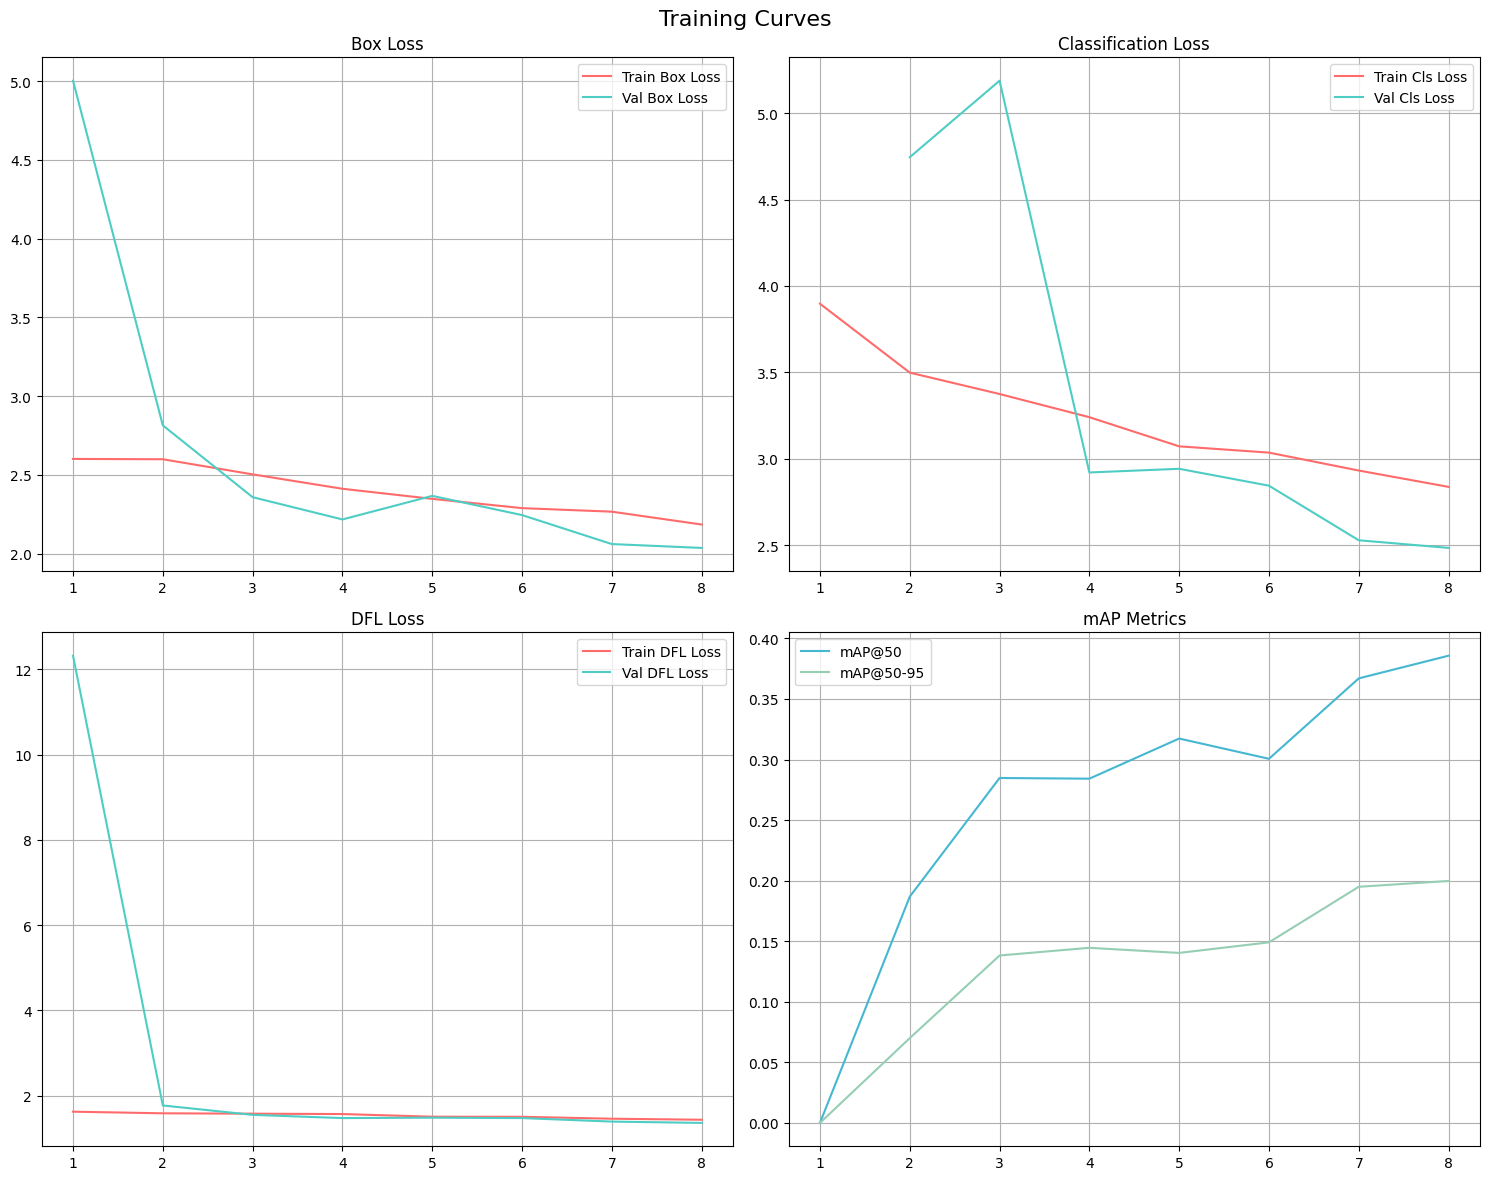


🔍 Plotting Confusion Matrix...
⚠️ Confusion matrix not found.

📊 Plotting Per-Class Metrics...


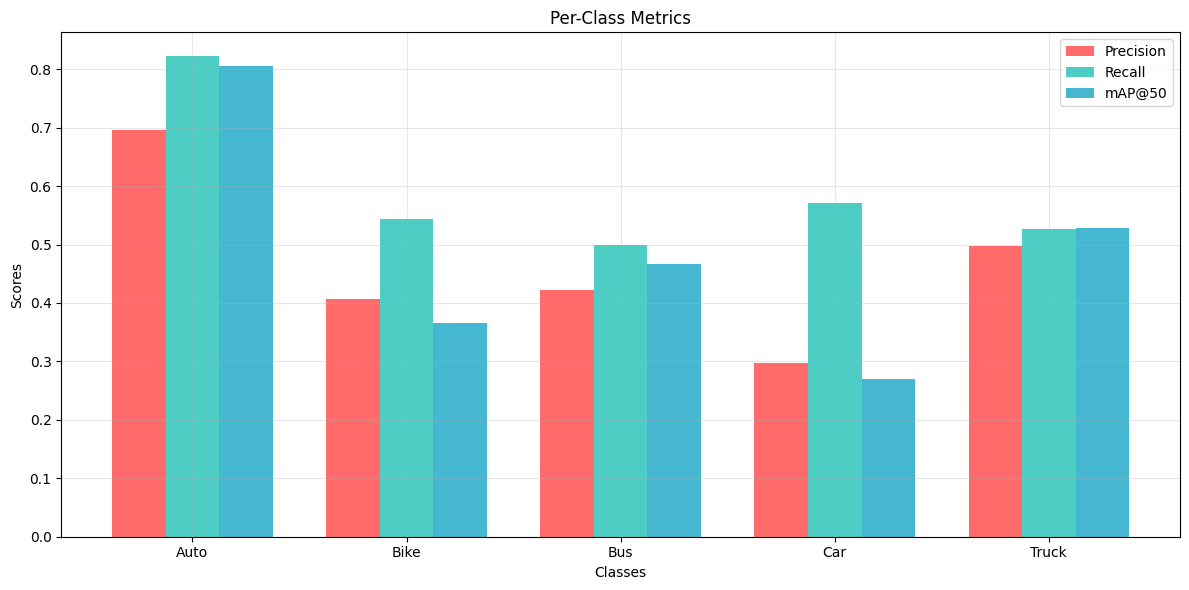


🖼️ Visualizing Sample Predictions...


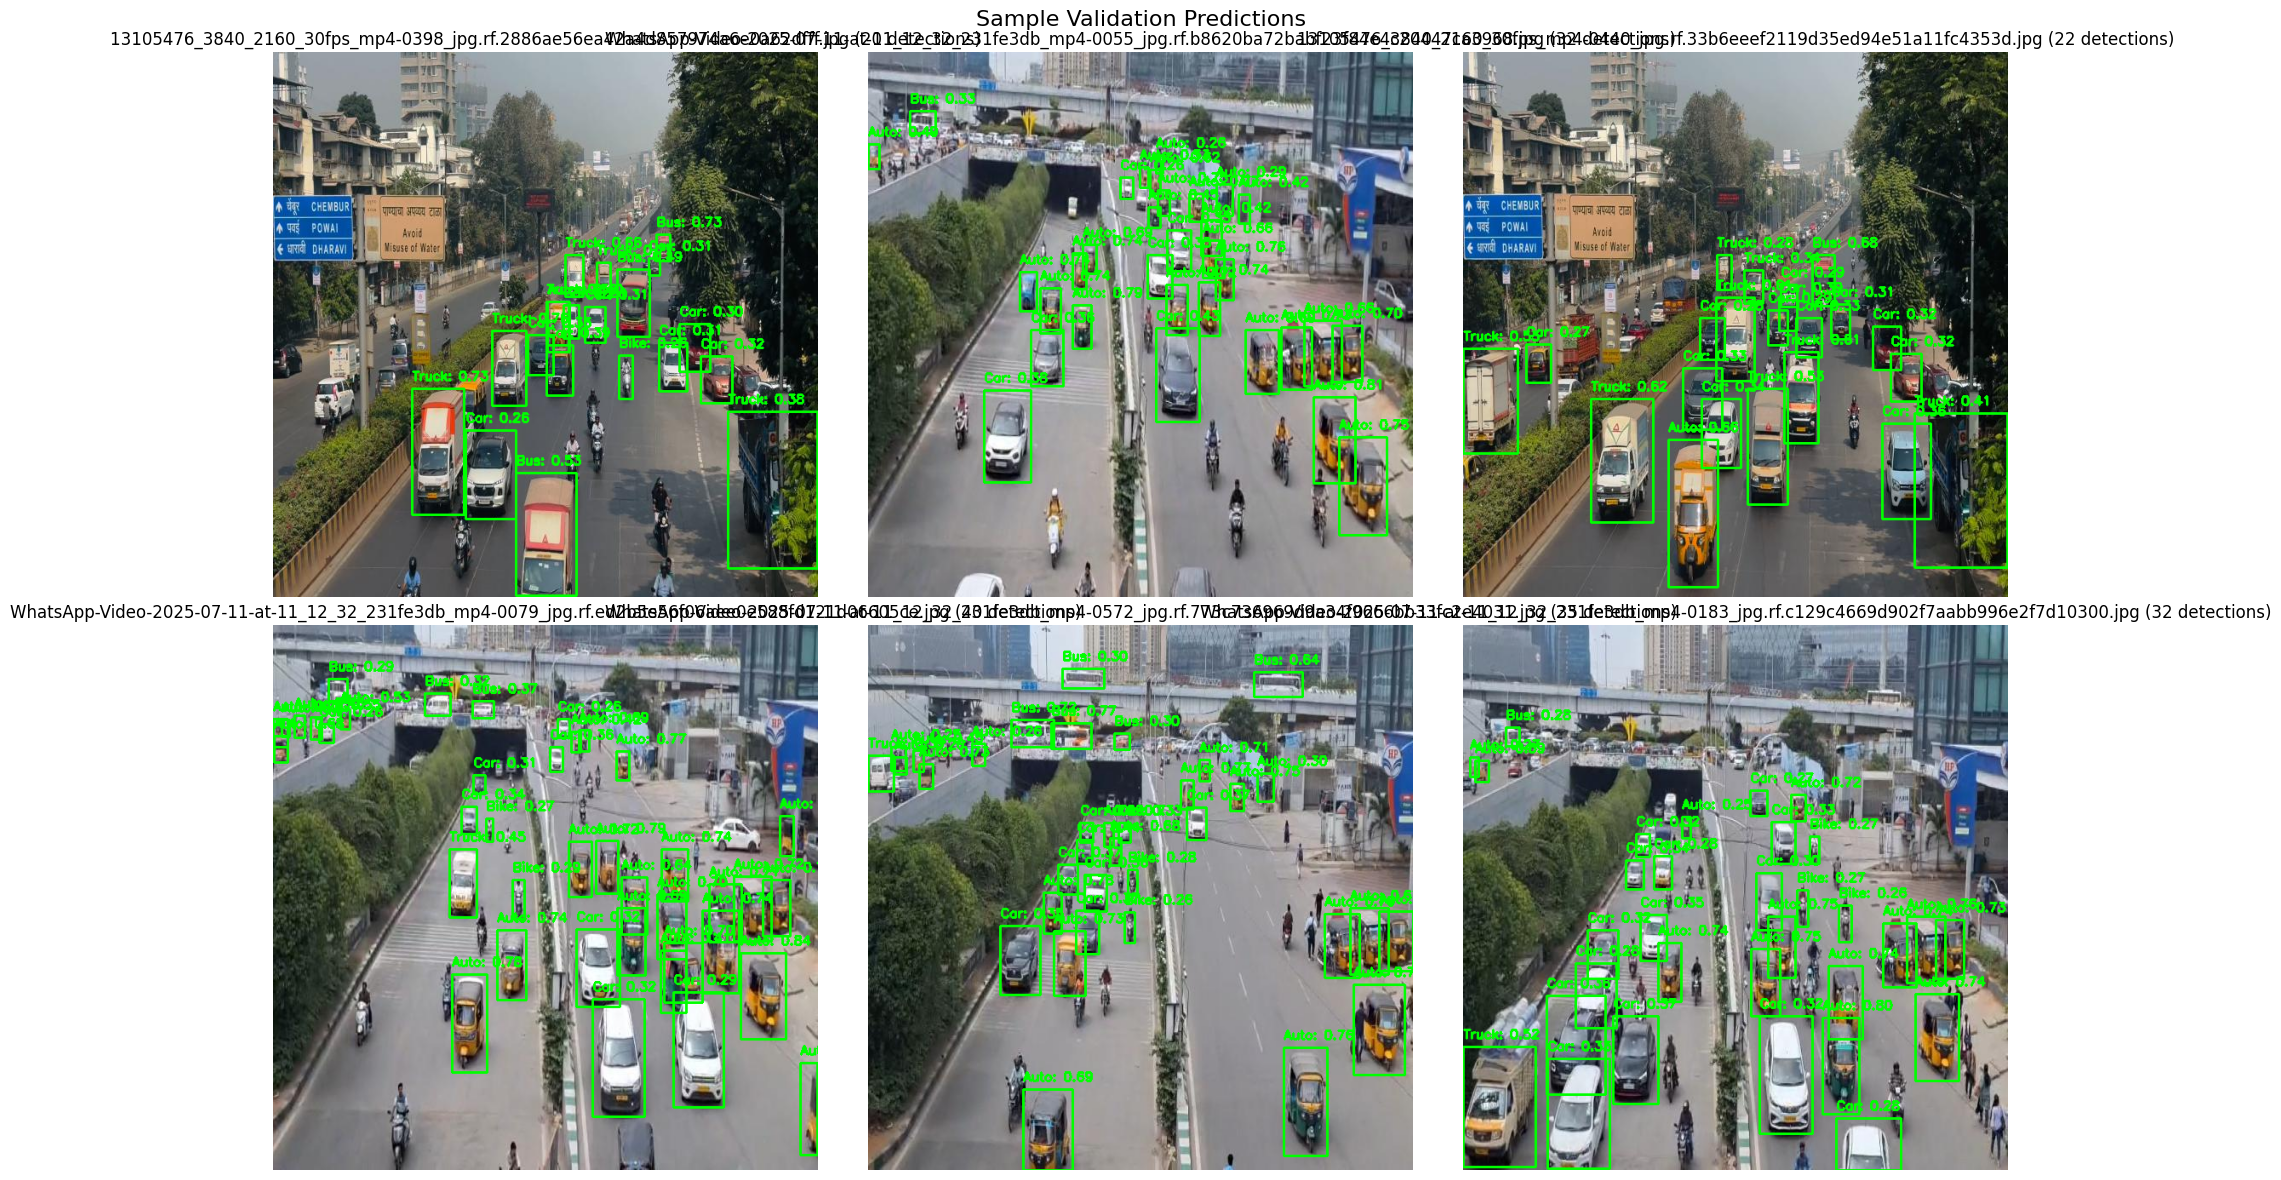


📋 Summary Table of Key Metrics


Metric,Value
Precision,0.464
Recall,0.593
mAP@50,0.488
mAP@50-95,0.331



🌐 Generating Simple HTML Dashboard...
✅ Dashboard saved to: /content/drive/MyDrive/Dataset/YOLO_training_aggressive/yolov8m_ultra_fast_90/dashboard.html
💡 Open in browser or use files.download(dashboard_path) to view.

🎉 Full Visualization Complete!


In [ ]:
# Full Visualization Script for YOLOv8 Training Results
# Visualizes: Training Curves, Confusion Matrix, Per-Class Metrics, Sample Predictions
# Run in Google Colab after training; assumes paths from previous scripts

import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
import cv2  # For image annotations if needed
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================
BASE_DIR = "/content/drive/MyDrive/Dataset"
PROJECT_DIR = os.path.join(BASE_DIR, "YOLO_training_aggressive")  # Update to your run dir
MODEL_NAME = "yolov8m_ultra_fast_90"  # Update to your model name
RUN_DIR = os.path.join(PROJECT_DIR, MODEL_NAME)
BEST_MODEL_PATH = os.path.join(RUN_DIR, "weights/best.pt")

# Colors for plots
COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

# ==================== LOAD DATA & MODEL ====================
if not os.path.exists(RUN_DIR):
    print(f"❌ Run directory not found: {RUN_DIR}")
    print("💡 Update PROJECT_DIR and MODEL_NAME to match your training run.")
    exit()

print(f"✅ Loading results from: {RUN_DIR}")

# Load model for predictions
if os.path.exists(BEST_MODEL_PATH):
    model = YOLO(BEST_MODEL_PATH)
    print("✅ Model loaded for predictions.")
else:
    print(f"⚠️ Best model not found: {BEST_MODEL_PATH}")
    model = None

# ==================== 1. TRAINING CURVES ====================
print("\n📈 Plotting Training Curves...")

# Load results CSV
results_csv = os.path.join(RUN_DIR, "results.csv")
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Training Curves', fontsize=16)

    # Losses
    axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color=COLORS[0])
    axes[0,0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color=COLORS[1])
    axes[0,0].set_title('Box Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)

    axes[0,1].plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss', color=COLORS[0])
    axes[0,1].plot(df['epoch'], df['val/cls_loss'], label='Val Cls Loss', color=COLORS[1])
    axes[0,1].set_title('Classification Loss')
    axes[0,1].legend()
    axes[0,1].grid(True)

    axes[1,0].plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss', color=COLORS[0])
    axes[1,0].plot(df['epoch'], df['val/dfl_loss'], label='Val DFL Loss', color=COLORS[1])
    axes[1,0].set_title('DFL Loss')
    axes[1,0].legend()
    axes[1,0].grid(True)

    # mAP
    axes[1,1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color=COLORS[2])
    axes[1,1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color=COLORS[3])
    axes[1,1].set_title('mAP Metrics')
    axes[1,1].legend()
    axes[1,1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ results.csv not found. Run training with plots=True.")

# ==================== 2. CONFUSION MATRIX ====================
print("\n🔍 Plotting Confusion Matrix...")

confusion_path = os.path.join(RUN_DIR, "confusion_matrix.png")
if os.path.exists(confusion_path):
    img = Image.open(confusion_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title('Confusion Matrix')
    plt.axis('off')
    plt.show()
else:
    print("⚠️ Confusion matrix not found.")

# ==================== 3. PER-CLASS METRICS ====================
print("\n📊 Plotting Per-Class Metrics...")

# Load results if available, or from val metrics
val_results_path = os.path.join(RUN_DIR, "val_batch0_labels.jpg")  # Or parse from logs
# For simplicity, hardcode from previous output; replace with actual if you have JSON
class_names = ['Auto', 'Bike', 'Bus', 'Car', 'Truck']
mAP50 = [0.806, 0.366, 0.467, 0.270, 0.529]  # From your last run; update dynamically if possible
precision = [0.696, 0.406, 0.422, 0.298, 0.498]  # Example values
recall = [0.822, 0.544, 0.500, 0.571, 0.526]

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, precision, width, label='Precision', color=COLORS[0])
ax.bar(x, recall, width, label='Recall', color=COLORS[1])
ax.bar(x + width, mAP50, width, label='mAP@50', color=COLORS[2])

ax.set_xlabel('Classes')
ax.set_ylabel('Scores')
ax.set_title('Per-Class Metrics')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== 4. SAMPLE PREDICTIONS ====================
print("\n🖼️ Visualizing Sample Predictions...")

if model:
    val_img_dir = os.path.join(BASE_DIR, "images/val")
    val_images = [f for f in os.listdir(val_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:6]  # Top 6

    if val_images:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.ravel()
        fig.suptitle('Sample Validation Predictions', fontsize=16)

        for idx, img_file in enumerate(val_images):
            img_path = os.path.join(val_img_dir, img_file)
            results = model.predict(img_path, conf=0.25, iou=0.45, save=False, verbose=False)

            # Load and annotate image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if results and results[0].boxes is not None:
                boxes = results[0].boxes.xyxy.cpu().numpy()
                classes = results[0].boxes.cls.cpu().numpy()
                confs = results[0].boxes.conf.cpu().numpy()

                for box, cls, conf in zip(boxes, classes, confs):
                    x1, y1, x2, y2 = map(int, box)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    label = f"{class_names[int(cls)]}: {conf:.2f}"
                    cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

            axes[idx].imshow(img)
            axes[idx].set_title(f"{img_file} ({len(boxes) if 'boxes' in locals() else 0} detections)")
            axes[idx].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("❌ No validation images found.")
else:
    print("⚠️ Model not loaded; skipping predictions.")

# ==================== 5. SUMMARY TABLE ====================
print("\n📋 Summary Table of Key Metrics")

# Example metrics; pull from results.csv for real
metrics_data = {
    'Metric': ['Precision', 'Recall', 'mAP@50', 'mAP@50-95'],
    'Value': [0.464, 0.593, 0.488, 0.331]  # From your last run
}

df_summary = pd.DataFrame(metrics_data)
display(HTML(df_summary.to_html(index=False, classes='table table-striped')))

# ==================== HTML DASHBOARD (Optional) ====================
print("\n🌐 Generating Simple HTML Dashboard...")

html_content = f"""
<!DOCTYPE html>
<html>
<head><title>YOLOv8 Viz Dashboard</title></head>
<body>
<h1>YOLOv8 Training Visualization</h1>
<p>Run Directory: {RUN_DIR}</p>
<img src="{os.path.join(RUN_DIR, 'results.png')}" alt="Results Plot" width="800">
<img src="{os.path.join(RUN_DIR, 'confusion_matrix.png')}" alt="Confusion Matrix" width="600">
<p>Per-Class mAP@50: Auto={mAP50[0]:.3f}, Bike={mAP50[1]:.3f}, Bus={mAP50[2]:.3f}, Car={mAP50[3]:.3f}, Truck={mAP50[4]:.3f}</p>
</body>
</html>
"""

dashboard_path = os.path.join(RUN_DIR, "dashboard.html")
with open(dashboard_path, 'w') as f:
    f.write(html_content)

print(f"✅ Dashboard saved to: {dashboard_path}")
print("💡 Open in browser or use files.download(dashboard_path) to view.")

print("\n🎉 Full Visualization Complete!")